In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# 2. Load Dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\E-Lab\Project3\master_analytical_view.csv")  
df.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,Churn
0,7590-VHVEG,1,29.85,29.850000,Month-to-month,DSL,Electronic check,No
1,5575-GNVDE,34,56.95,1889.500000,One year,DSL,Mailed check,No
2,3668-QPYBK,2,53.85,108.150002,Month-to-month,DSL,Mailed check,Yes
3,7795-CFOCW,45,42.30,1840.750000,One year,DSL,Bank transfer (automatic),No
4,9237-HQITU,2,70.70,151.649994,Month-to-month,Fiber optic,Electronic check,Yes


In [3]:
# 3. Data Cleaning
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
# Drop missing values
df.dropna(inplace=True)

In [6]:
# Drop customerID (IMPORTANT)
df.drop('customerID', axis=1, inplace=True)

In [7]:
# 4. Convert Target Variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

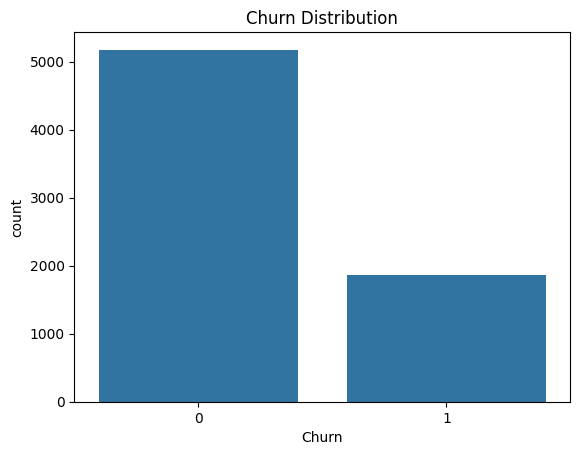

In [8]:
# 5. Exploratory Data Analysis (EDA)
# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

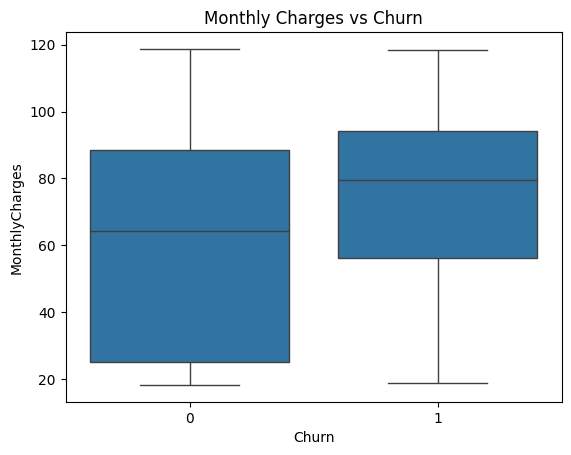

In [9]:
# Monthly charges vs churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [10]:
# 6. Encode Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [11]:
# 7. Split Data
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# 8. Model Building
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [13]:
# 9. Prediction
y_pred = model.predict(X_test)

In [14]:
# 10. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7814052519517388

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86      1036
           1       0.60      0.51      0.55       373

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



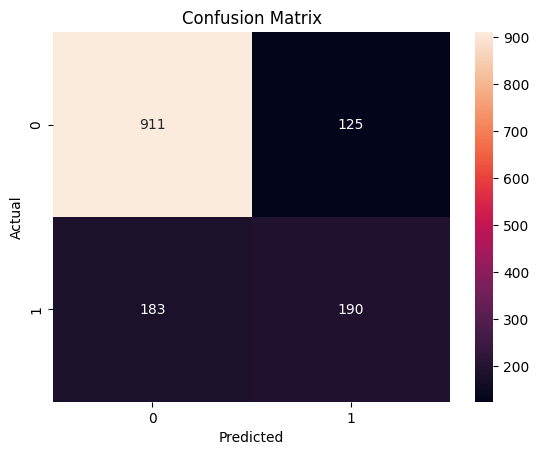

In [15]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


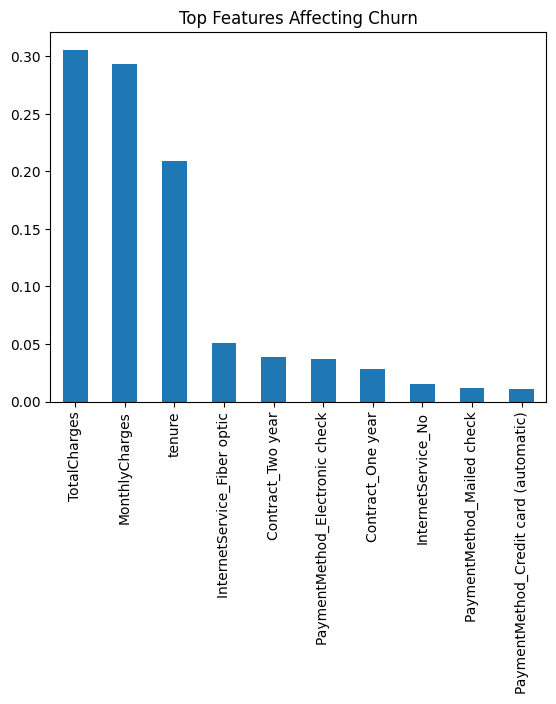

In [16]:
# 11. Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

In [17]:
# 12. Customer Segmentation
df['Segment'] = np.where(df['Churn'] == 1, "At Risk", "Loyal")
print(df[['Segment']].value_counts())


Segment
Loyal      5174
At Risk    1869
Name: count, dtype: int64


In [18]:
# 13. Save Model
import pickle
with open("churn_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model saved successfully!")

Model saved successfully!
